<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:dcb7a647-dc9f-48bb-85f5-72e4da5d9f1e.jpg" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---

# <h1><center>Actividad 12 - Aprendizaje no supervisado</center></h1>

Esta actividad busca aplicar técnicas de reducción de dimensionalidad y clustering para diferenciar y representar imágenes sencillas.

## Instrucciones

Esto Notebook contiene las instrucciones a realizar para la actividad. 

<b>Al finalizarla, deben subir el Notebook y los archivos generados en un único archivo .zip, al módulo de la Actividad 12 en Canvas.</b>

## Datos

Para esta actividad, trabajaremos con la base de datos de imágenes [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist). Cada una de estas corresponde a una pequeña imagen de alguna prenda de ropa o accesorio de 28x28 pixeles en escala de grises.


## Rúbrica

- Si han logrado todo: 7.0
- Si han logrado sólo hasta el punto 2: 5.0
- Menos que eso: 1.0


## 1. Crear DataFrame

Primero lea el archivo `fashion-mnist_test.csv` y cárguelo en un dataframe.

* A Cree un DataFrame $X$ que contenga solamente la información de los pixeles de las imágenes.
* B Cree un vector $y$ que contenga la etiqueta de las imágenes de $X$.
* C Muestre la cantidad de filas que tiene cada etiqueta de su DataFrame. Puede hacer esto con un histograma sencillo o imprimiendo las cantidades de filas según su clase.

In [1]:
# algunas librerías útiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# respuestas
df = pd.read_csv('fashion-mnist_test.csv')
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


None

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# A basicamente solo hay que botar la columna label (etiqueta)
X = df.drop('label', axis=1)

# B (datarame de las etiquetas)
y = df['label']

### Visualización de las imágenes del dataset
La siguiente celda le permitirá visualizar una muestra de cada una de las clases contenidas en su dataset. Con su `X` e `y` ya definidos, corra el código sin modificar la celda. (Puede correrla múltiples veces para obtener muestras distintas de las imágenes.)

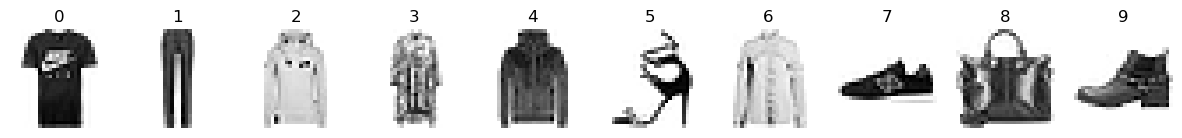

In [8]:
def get_index_by_class(i, y):
  y = pd.DataFrame(y)
  return y[y['label'] == i].sample(1).index[0]

def show_images(images, labels, figsize=(5,5)):
  f, ax = plt.subplots(1, len(images), figsize=figsize)
  for i, im in enumerate(images):
    image = im.values.reshape(28,28)
    label = labels[i]
    if len(images) == 1:
      plt.imshow(image, cmap='binary')
      plt.axis('off')
      break
    ax[i].imshow(image, cmap='binary')
    ax[i].axis('off')
    ax[i].set_title(label)
  plt.show()

targets = list(range(10))
sample_image_ids = [get_index_by_class(i, y) for i in targets]
images = [X.iloc[i] for i in sample_image_ids]

show_images(images, targets, figsize=(15, 5))

## 2. Reducción de dimensionalidad

### 2.1 PCA
Aplique el algoritmo PCA a su muestra `X`, representando todas las imágenes en sus 2 componentes principales. Almaece estos nuevos resultados en el dataframe `X_pca`, que contenga las columnas `pc1` y `pc2`.

Luego muestre un scatterplot de su dataset, utilizando el color de cada punto para representar la clase original a la que pertenece la imagen.

### 2.2 tSNE
Vamos a experimentar con otro método de reducción de dimensionalidad llamado tSNE ([*T-ditributed Stochastic Neighbor Embedding*](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding)). Puede encontrar [la documentación del método aquí.](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
Este algoritmo corre en tiempo cuadrático a la cantidad de datos, por lo que tardará un poco más que PCA.

Nuevamente, reduzca la dimensionalidad de su dataset a 2 dimensiones utilizando este nuevo método. Almaece los resultados en el dataframe `X_tsne`, que contenga las columnas `dim1` y `dim2`.

Grafique el mismo scatterplot que realizó con PCA.


Responda:
* ¿Cómo se diferencian estos dos gráficos? ¿Qué clases parecen ser "fáciles de diferenciar" y cuáles no? ¿Tiene sentido con los datos originales? Comente sus observaciones. 

In [10]:
# algunas librerías útiles
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
# respuestas 2.1
pca = PCA(n_components=2) #para pca1 y pca2
X_pca_data = pca.fit_transform(X)
X_pca = pd.DataFrame(X_pca_data, columns=['pc1', 'pc2'])
X_pca

,pc1,pc2
0,1392.064915,-333.901261
1,-39.661533,-1565.228715
2,-828.821342,-144.303630
3,783.866498,213.744124
4,264.855753,-965.017442
...,...,...
9995,329.122306,-632.863668
9996,-613.626924,-321.287337
9997,254.329470,1012.857905
9998,1529.898732,1356.974024


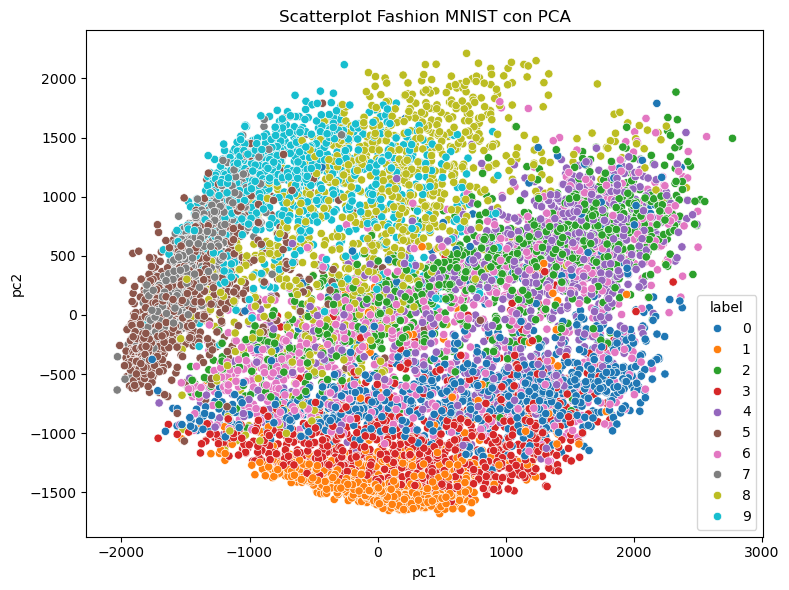

In [16]:
#scaterrplot X_pca
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='pc1', y='pc2', hue=y, palette='tab10', data=X_pca, ax=ax, legend='full')
ax.set_title('Scatterplot Fashion MNIST con PCA')
plt.tight_layout()
plt.show()

Respuesta:

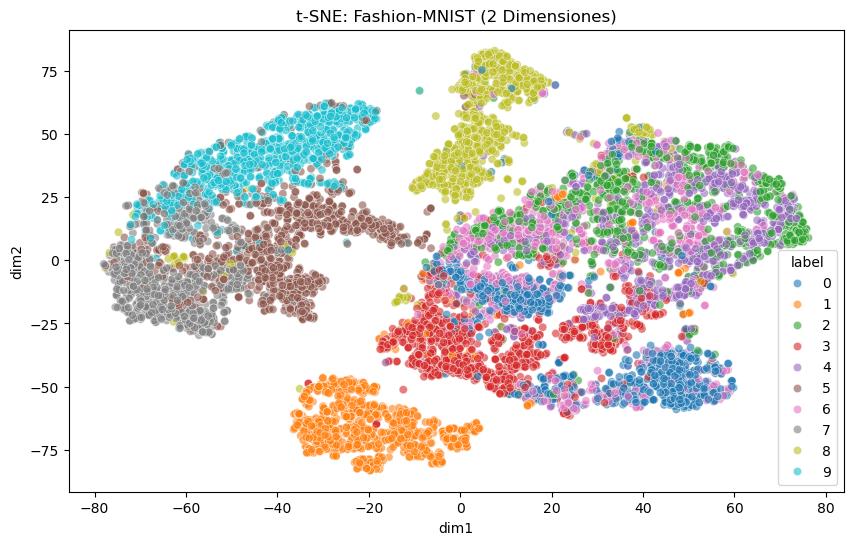

In [ ]:
#respuesta 2.2
tsne = TSNE(n_components=2, random_state=42) 
X_tsne_array = tsne.fit_transform(X)

X_tsne = pd.DataFrame(X_tsne_array, columns=['dim1', 'dim2'])

# grafico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_tsne, x='dim1', y='dim2', hue=y, palette='tab10', legend='full', alpha=0.6)
plt.title('t-SNE: Fashion-MNIST (2 Dimensiones)')
plt.show()

Notemos que con `PCA` obtenemos un scatterplot bastante mezclado, lo que no facilita una comprensión de los datos. En su contraparte, `T_SNE` logra separar las clases en varios grupos fácilmente reconocibles. Esto puede deberse a que PCA es un algoritmo lineal que aplasta todo y T-SNE revisa vecinos a cada punto.

## 3. Clustering

### 3.1 KMeans

1. Aplique el algoritmo **KMeans** para agrupar sus imágenes en `X_pca`. Seleccione una cantidad de clusters igual a la cantidad de clases que tiene (10). Luego, muestre dos scatterplot: el primero siendo el mismo que mostró en la sección 2.1, donde los colores de cada punto simbolizan su clase original; y el segundo donde el color represente el cluster que encotró con KMeans. Recuerde colocarle un título informativo a cada uno.

2. Repita este mismo proceso para `X_tsne`.

3. Para ambos puntos anteriores, comente sus visualizaciones. ¿Hay una relación entre el clusters encontrados y las clases originales de las imágenes?

In [19]:
# algunas librearías útiles
from sklearn.cluster import KMeans


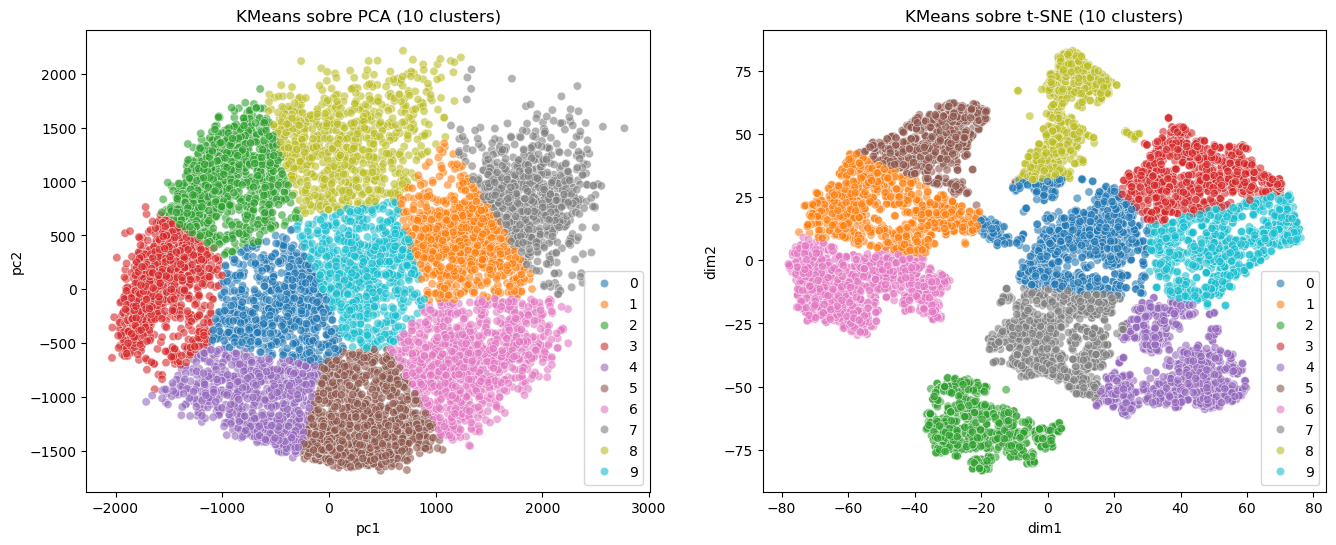

In [21]:
# respuestas
kmeans_pca = KMeans(n_clusters=10, random_state=42, n_init='auto')
labels_pca = kmeans_pca.fit_predict(X_pca)

kmeans_tsne = KMeans(n_clusters=10, random_state=42, n_init='auto')
labels_tsne = kmeans_tsne.fit_predict(X_tsne)

# grafico los resultados
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(data=X_pca, x='pc1', y='pc2', hue=labels_pca, palette='tab10', ax=axes[0], legend='full', alpha=0.6)
axes[0].set_title('KMeans sobre PCA (10 clusters)')

sns.scatterplot(data=X_tsne, x='dim1', y='dim2', hue=labels_tsne, palette='tab10', ax=axes[1], legend='full', alpha=0.6)
axes[1].set_title('KMeans sobre t-SNE (10 clusters)')

plt.show()


### 3.2 DBSCAN


Para concluir, probaremos con DBSCAN como método de clustering.

1. Primero, ¿cuáles son los 2 principales parámetros que recibe el método `DBSCAN`? ¿Qué significan?

2. Experimente con estos hiperparámetros para aplican DBSCAN sobre `X_pca` y `X_tsne`, de tal forma que el algoritmo encuentre **al menos** dos clusters diferentes. Finalmente, grafique los scatterplots correspondiente a los nuevos clusters encontrados.

Los parámetros son:
* `eps`: este parámetro representa la mínima distancia entre dos puntos para que el algoritmo los considere "vecinos".
* `min_samples`: la mínima cantidad de puntos que tiene que haber en un vecindario para que un punto sea considerado un "core point".

In [ ]:
# algunas librearías útiles
from sklearn.cluster import DBSCAN


In [ ]:
# respuestas